In [28]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [105]:
# Define constants
STATES = ["Michigan", "Indiana", "Illinois"]

In [137]:
tax = pd.read_csv("tax.csv")
tax = tax[tax["State"].isin(STATES)]
tax = tax[tax["Year"] < 2025]

econ = pd.read_csv("economics.csv")
econ = econ[econ["State"].isin(STATES)]
econ = econ[(econ["Year"] < 2025) & (econ["Year"] > 2004)]

In [107]:
tax

,Year,Quarter,State,Tax_Category,Tax_Code,Amount
325,2004,1,Illinois,Property tax,T01,15462.0
326,2004,1,Illinois,General sales and gross receipts,T09,1644562.0
327,2004,1,Illinois,Alcoholic beverages,T10,29456.0
328,2004,1,Illinois,Amusements,T11,134509.0
329,2004,1,Illinois,Insurance,T12,92321.0
...,...,...,...,...,...,...
108470,2024,4,Michigan,Corporation net income,T41,671987.0
108471,2024,4,Michigan,Death and gift,T50,0.0
108472,2024,4,Michigan,Documentary and stock transfer,T51,107869.0
108473,2024,4,Michigan,Severance,T53,4770.0


In [108]:
tax.groupby(["Year", "State", "Tax_Code"])["Amount"].sum().reset_index()

,Year,State,Tax_Code,Amount
0,2004,Illinois,T01,55207.0
1,2004,Illinois,T09,7032948.0
2,2004,Illinois,T10,138476.0
3,2004,Illinois,T11,806467.0
4,2004,Illinois,T12,393898.0
...,...,...,...,...
1573,2024,Michigan,T41,3207877.0
1574,2024,Michigan,T50,6.0
1575,2024,Michigan,T51,401324.0
1576,2024,Michigan,T53,24414.0


In [109]:
tax_piv = tax.groupby(["Year", "State", "Tax_Code"])["Amount"].sum().reset_index()
tax_piv = pd.pivot_table(tax_piv, index=["Year", "State"], columns="Tax_Code", values="Amount")
tax_piv = tax_piv.fillna(0)
tax_piv["Total"] = tax_piv.sum(axis=1)
for col in tax_piv.columns:
    tax_piv[col] = (tax_piv[col] / tax_piv["Total"]) * 100

tax_piv["sin"] = tax_piv[["T10", "T11", "T14", "T16", "T18", "T20", "T21"]].sum(axis=1)
tax_piv["property"] = tax_piv["T01"]
tax_piv["sales"] = tax_piv["T09"]
tax_piv["corpit"] = tax_piv[["T22", "T28", "T41"]].sum(axis=1)
tax_piv = tax_piv[["sin", "property", "corpit", "sales"]].reset_index()
tax_piv.shape

(63, 6)

In [110]:
tax_piv

Tax_Code,Year,State,sin,property,corpit,sales
0,2004,Illinois,6.754511,0.225715,10.327737,28.754408
1,2004,Indiana,9.451733,0.081288,6.888849,39.400116
2,2004,Michigan,5.910930,10.580867,9.146141,34.577579
3,2005,Illinois,5.918028,0.224226,11.533678,27.574535
4,2005,Indiana,9.011546,0.059228,7.348030,39.270024
...,...,...,...,...,...,...
58,2023,Indiana,4.317854,0.000000,5.179963,42.201142
59,2023,Michigan,3.182627,7.258624,8.839917,32.951221
60,2024,Illinois,3.979875,0.110208,18.265096,23.526840
61,2024,Indiana,4.135993,0.000000,4.106121,42.130776


In [132]:
def generate_trend_by_state(data, col):
    
    plt.figure(figsize=(11, 7))

    sns.lineplot(
        data=data,
        x="Year",
        y=col,
        hue="State",
        marker="o"
    )

    plt.xticks(data["Year"].unique())

    # Labels and title
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.title(f"{col} Trends by State")
    plt.legend(title="State")

    # Show plot
    plt.show()

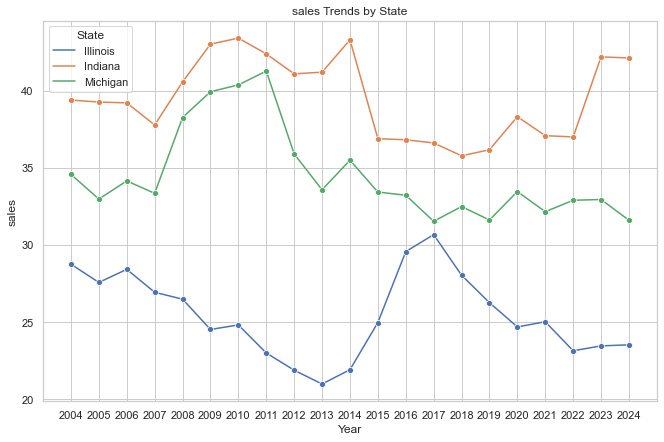

In [133]:
generate_trend_by_state(tax_piv, "sales")

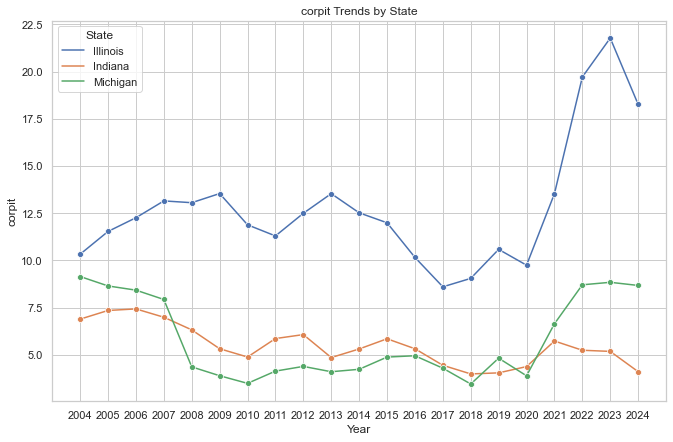

In [134]:
generate_trend_by_state(tax_piv, "corpit")

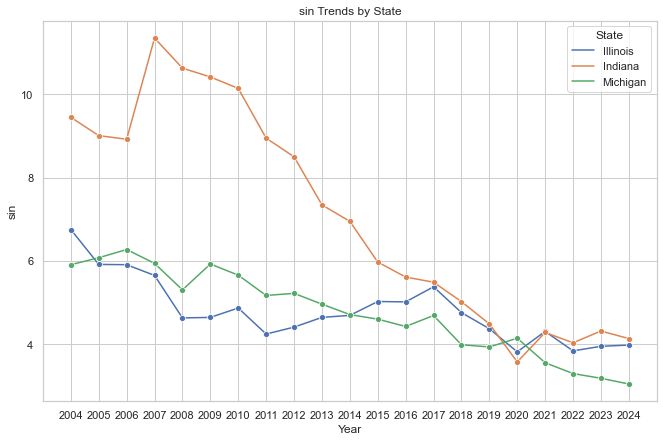

In [135]:
generate_trend_by_state(tax_piv, "sin")

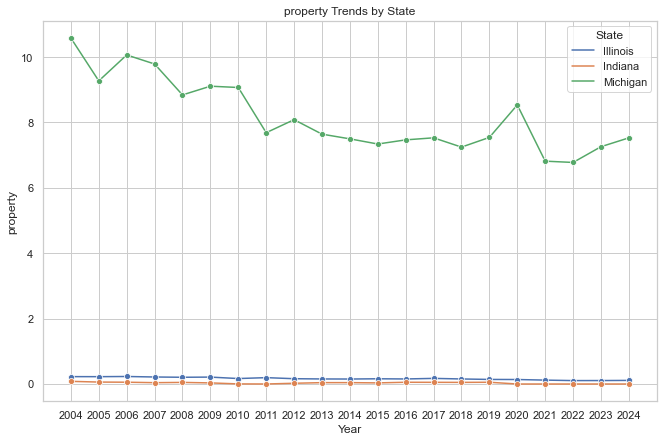

In [136]:
generate_trend_by_state(tax_piv, "property")

In [166]:
econ_piv = econ.groupby(["State", "Year"]).agg({
    "GDP_Total": "sum",
    "GDP_Real_Estate": "sum",
    "Unemployment_Rate": "mean",
    "Housing_Price_Index": "mean",
    "% Civilian Labor Force Unemployed": "mean",
    "Applications": "sum",
    "Formations": "sum",
    "Population": "max",
}).reset_index()

econ_piv["Business_Formation_per_100k"] = (
    (econ_piv["Formations"] / econ_piv["Population"]) * 100000
)

econ_piv["Business_Applications_per_100k"] = (
    (econ_piv["Applications"] / econ_piv["Population"]) * 100000
)

econ_piv.head()

,State,Year,GDP_Total,GDP_Real_Estate,Unemployment_Rate,Housing_Price_Index,% Civilian Labor Force Unemployed,Applications,Formations,Population,Business_Formation_per_100k,Business_Applications_per_100k
0,Illinois,2005,2356614.6,293305.9,5.7350,197.2925,5.775,96158,16008,12635442,126.691255,761.018095
1,Illinois,2006,2496272.2,301682.3,4.6225,207.2075,4.700,98492,14962,12682888,117.969977,776.573916
2,Illinois,2007,2597229.5,326064.3,5.0600,208.4900,4.975,100504,14132,12734245,110.976348,789.241922
3,Illinois,2008,2598709.1,335704.9,6.5100,195.3475,6.300,104692,12278,12784343,96.039351,818.907941
4,Illinois,2009,2583372.9,341401.3,9.9675,181.6325,9.675,96821,11319,12819691,88.293860,755.252213


In [148]:
def generate_index_trend(col, data=econ_piv, baseline_year=2005):

    baseline = (
        data[data["Year"] == baseline_year]
        .set_index("State")[col]
    )

    data[f"{col}_Index"] = data.apply(
        lambda row: (row[col] / baseline[row["State"]]) * 100,
        axis=1
    )

    plt.figure(figsize=(11, 7))

    sns.lineplot(
        data=data,
        x="Year",
        y=f"{col}_Index",
        hue="State",
        marker="o"
    )

    plt.xticks(data["Year"].unique())

    # Labels
    plt.xlabel("Year")
    plt.ylabel(f"{col} Index ({baseline_year} = 100)")
    plt.title(f"State GDP Growth Indexed to {baseline_year}")

    plt.legend(title="State")

    # Show
    plt.show()

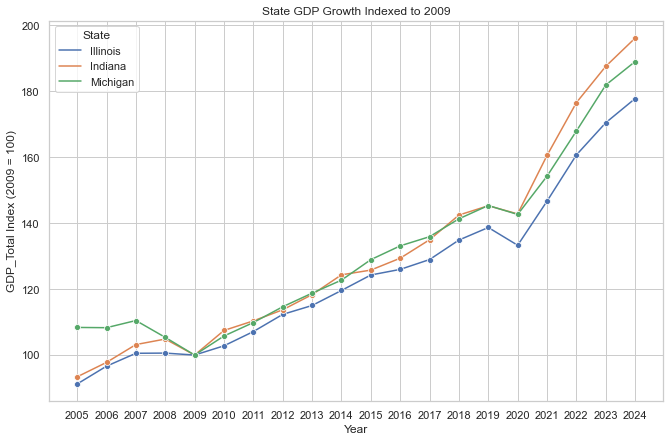

In [171]:
generate_index_trend("GDP_Total", baseline_year=2009)

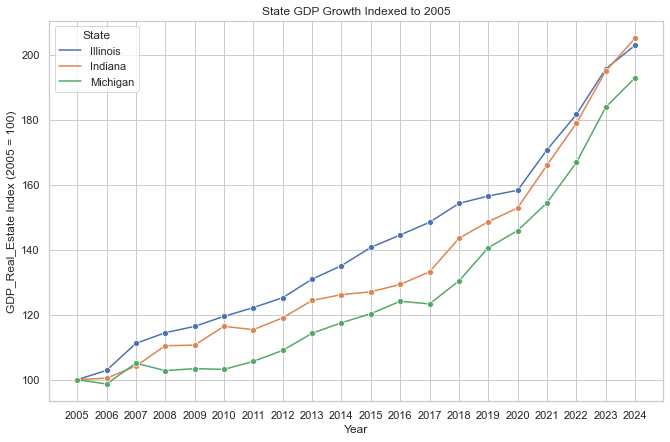

In [151]:
generate_index_trend("GDP_Real_Estate")

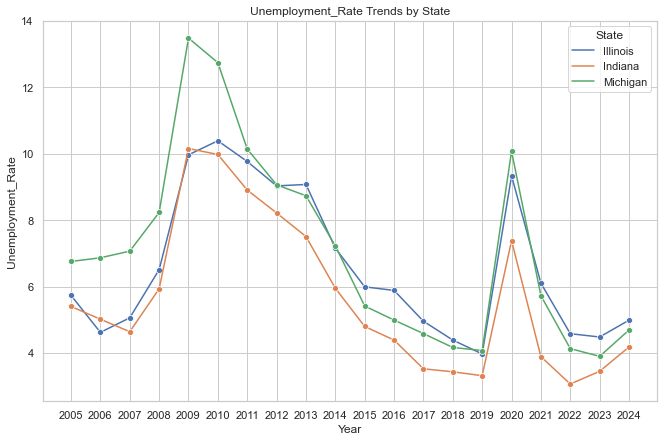

In [152]:
generate_trend_by_state(econ_piv, "Unemployment_Rate")

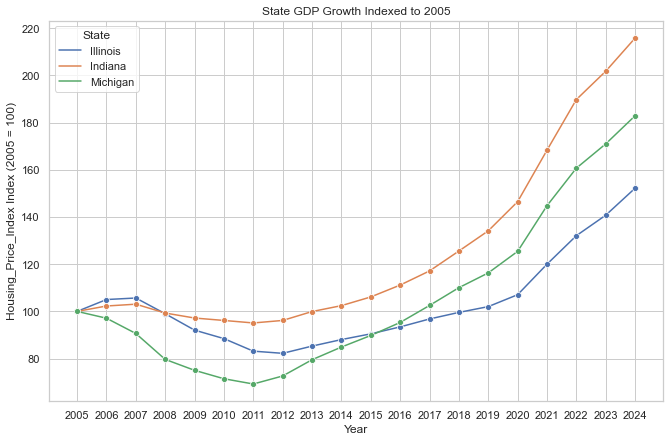

In [156]:
generate_index_trend("Housing_Price_Index", econ_piv)

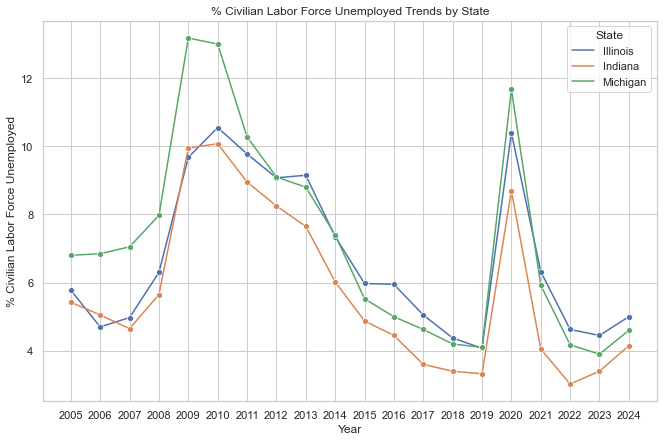

In [160]:
generate_trend_by_state(econ_piv, "% Civilian Labor Force Unemployed")

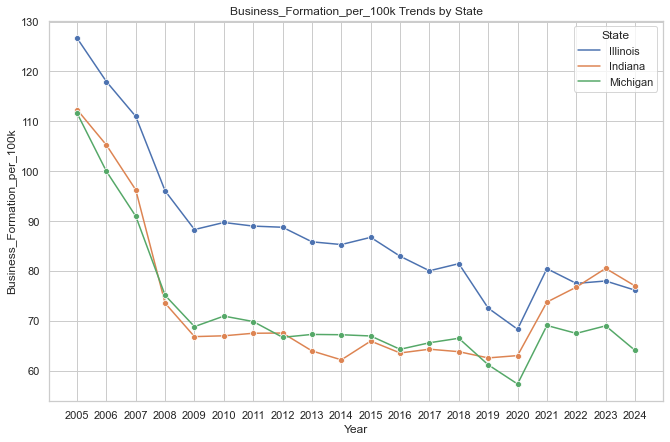

In [168]:
generate_trend_by_state(econ_piv, "Business_Formation_per_100k")

In [142]:
list(econ.columns)

['State',
 'Year',
 'Quarter',
 'Population',
 'Unemployment_Rate',
 'Civilian noninstitutional population',
 'Total Civilian Labor Force',
 'Total Employed Civilian Labor Force',
 'Total Unemployed Civilian Labor Force',
 '% Civilian Labor Force Unemployed',
 'Personal_Income',
 'Applications',
 'Formations',
 'Births',
 'GDP_Total',
 'GDP_Accom_Food',
 'GDP_Admin_Waste',
 'GDP_Ag_Fish_Hunt',
 'GDP_Arts_Recreation',
 'GDP_Construction',
 'GDP_Durable_Goods',
 'GDP_Education',
 'GDP_Finance_Insurance',
 'GDP_Gov_Federal',
 'GDP_Gov_Military',
 'GDP_Gov_State_Local',
 'GDP_Gov_Total',
 'GDP_Healthcare_Social',
 'GDP_Information',
 'GDP_Management',
 'GDP_Manufacturing',
 'GDP_Mining_Oil_Gas',
 'GDP_Nondurable_Goods',
 'GDP_Other_Services',
 'GDP_Private_Total',
 'GDP_Prof_Tech_Services',
 'GDP_Real_Estate',
 'GDP_Retail',
 'GDP_Transport_Warehousing',
 'GDP_Utilities',
 'GDP_Wholesale',
 'Housing_Price_Index']

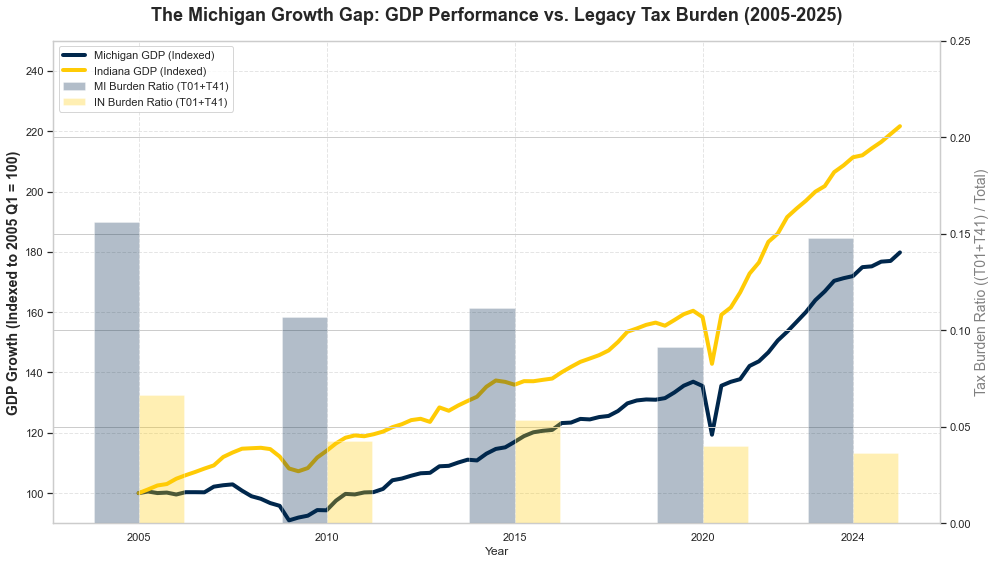

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Datasets
tax_df = pd.read_csv('tax.csv')
econ_df = pd.read_csv('economics.csv')

# 2. Pivot Tax Data to isolate Corporate (T41) and State Property (T01) Taxes
tax_pivot = tax_df.groupby(['State', 'Year', 'Quarter', 'Tax_Code'])['Amount'].sum().unstack(fill_value=0).reset_index()
tax_codes = [c for c in tax_pivot.columns if c.startswith('T')]
tax_pivot['Total_Taxes'] = tax_pivot[tax_codes].sum(axis=1)

# 3. Merge with Economic Indicators
merged = pd.merge(econ_df, tax_pivot, on=['State', 'Year', 'Quarter'], how='inner')

# 4. Filter for Comparison: Michigan vs. Indiana
target_states = ['Michigan', 'Indiana']
df_plot = merged[merged['State'].isin(target_states)].copy()
df_plot['Date'] = df_plot['Year'] + (df_plot['Quarter'] - 1) / 4

# 5. Calculate Metrics: Indexed GDP and Tax Burden Ratio
# Indexed GDP: 2005 Q1 = 100
def index_gdp(group):
    group = group.sort_values('Date')
    base_val = group.iloc[0]['GDP_Total']
    group['GDP_Indexed'] = (group['GDP_Total'] / base_val) * 100
    return group

df_plot = df_plot.groupby('State').apply(index_gdp).reset_index(drop=True)

# Burden Ratio = (Property Tax + Corporate Tax) / Total Taxes
df_plot['Tax_Burden_Ratio'] = (df_plot['T01'] + df_plot['T41']) / df_plot['Total_Taxes']

# 6. Aggregate Bar Data for 5-Year Intervals
bar_years = [2005, 2010, 2015, 2020, 2024]
df_bars = df_plot[df_plot['Year'].isin(bar_years)].groupby(['State', 'Year'])['Tax_Burden_Ratio'].mean().reset_index()

# 7. Create the Dual-Axis Visualization
fig, ax1 = plt.subplots(figsize=(14, 8))

# Primary Axis: Line Chart for Indexed GDP
colors = {'Michigan': '#00274C', 'Indiana': '#FFCB05'} # Michigan Blue & Gold-ish
for state in target_states:
    state_data = df_plot[df_plot['State'] == state].sort_values('Date')
    ax1.plot(state_data['Date'], state_data['GDP_Indexed'], label=f'{state} GDP (Indexed)', linewidth=4, color=colors[state])

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('GDP Growth (Indexed to 2005 Q1 = 100)', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(90, 250)

# Secondary Axis: Bar Chart for Tax Burden
ax2 = ax1.twinx()
width = 1.2
mi_burdens = df_bars[df_bars['State'] == 'Michigan']['Tax_Burden_Ratio'].values
in_burdens = df_bars[df_bars['State'] == 'Indiana']['Tax_Burden_Ratio'].values

ax2.bar(np.array(bar_years) - 0.6, mi_burdens, width=width, alpha=0.3, color='#00274C', label='MI Burden Ratio (T01+T41)')
ax2.bar(np.array(bar_years) + 0.6, in_burdens, width=width, alpha=0.3, color='#FFCB05', label='IN Burden Ratio (T01+T41)')

ax2.set_ylabel('Tax Burden Ratio ((T01+T41) / Total)', fontsize=14, color='gray')
ax2.set_ylim(0, 0.25)

# Formatting
plt.xticks(df_bars["Year"].unique())
plt.title('The Michigan Growth Gap: GDP Performance vs. Legacy Tax Burden (2005-2025)', fontsize=18, fontweight='bold', pad=20)
lines, labels = ax1.get_legend_handles_labels()
bars, bar_labels = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + bar_labels, loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('michigan_growth_gap_exploratory.png')

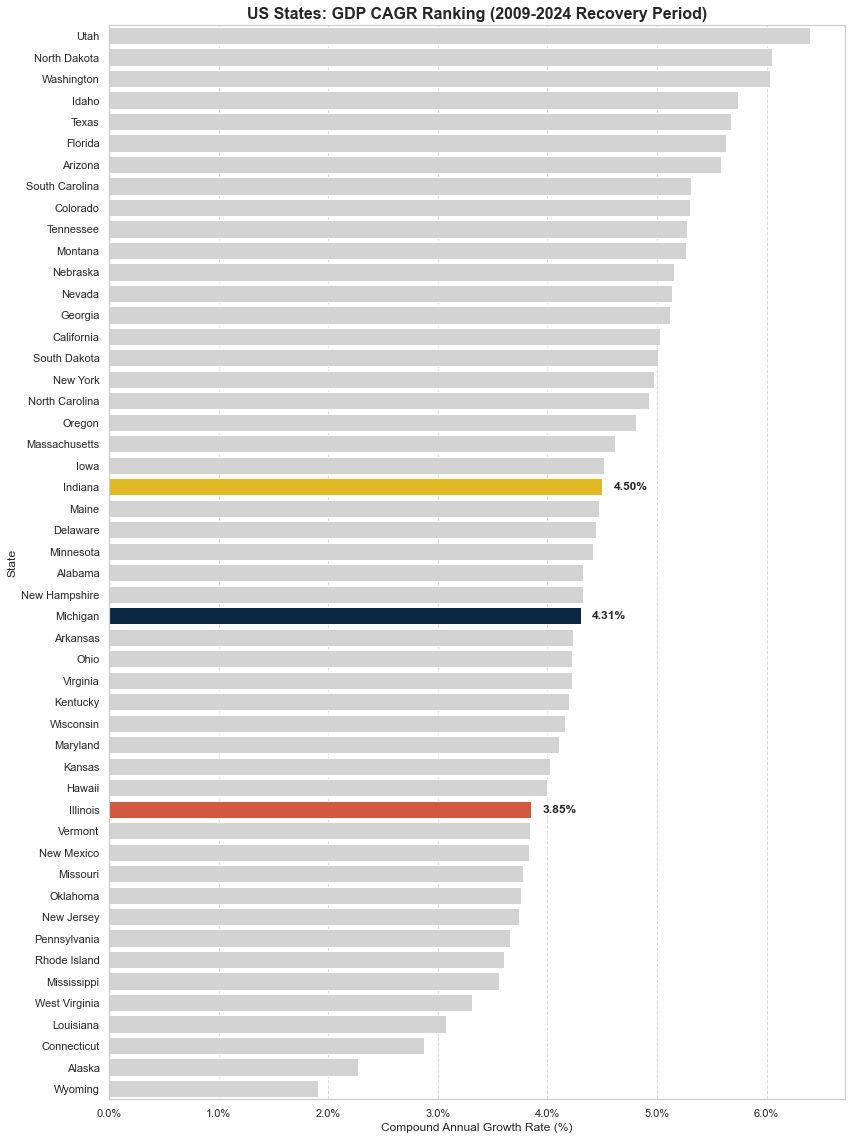

In [173]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Load data
econ_df = pd.read_csv('economics.csv')

# 2. Filter for 2009-2024 Recovery Period
df_filtered = econ_df[(econ_df['Year'] >= 2009) & (econ_df['Year'] <= 2024) & 
                      (~econ_df['State'].isin(['US Total', 'United States', 'District of Columbia']))].copy()

# 3. Calculate CAGR
def calculate_cagr(group):
    group = group.sort_values(['Year', 'Quarter'])
    start_val = group.iloc[0]['GDP_Total']
    end_val = group.iloc[-1]['GDP_Total']
    n_years = (len(group) - 1) / 4.0
    return pd.Series({'CAGR': (end_val / start_val)**(1/n_years) - 1})

state_cagr = df_filtered.groupby('State').apply(calculate_cagr).reset_index().sort_values('CAGR', ascending=False)

# 4. Highlight Palette
highlight_states = ['Michigan', 'Indiana', 'Illinois']
palette = {state: 'lightgrey' for state in state_cagr['State']}
palette['Michigan'], palette['Indiana'], palette['Illinois'] = '#00274C', '#FFCB05', '#E84A27'

# 5. Plotting
plt.figure(figsize=(12, 16))
ax = sns.barplot(
    data=state_cagr, 
    x='CAGR', 
    y='State', 
    palette=[palette[s] for s in state_cagr['State']]
)

# 6. Add Percentage Labels to Highlighted States
for i, p in enumerate(ax.patches):
    state_name = state_cagr.iloc[i]['State']
    if state_name in highlight_states:
        width = p.get_width()
        ax.text(
            width + 0.001,                   # Position just to the right of the bar
            p.get_y() + p.get_height() / 2,  # Vertically centered in the bar
            f'{width:.2%}',                 # Format as percentage with 2 decimals
            ha='left', 
            va='center', 
            fontsize=12, 
            fontweight='bold'
        )

# Formatting
plt.title('US States: GDP CAGR Ranking (2009-2024 Recovery Period)', fontsize=16, fontweight='bold')
plt.xlabel('Compound Annual Growth Rate (%)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('state_gdp_cagr_labeled.png')

In [175]:
econ[["State", "Year", "GDP_Real_Estate"]]

,State,Year,GDP_Real_Estate
1066,Illinois,2005,71852.3
1067,Illinois,2005,73851.7
1068,Illinois,2005,74995.0
1069,Illinois,2005,72606.9
1070,Illinois,2006,74665.8
...,...,...,...
1879,Michigan,2023,95213.7
1880,Michigan,2024,95772.7
1881,Michigan,2024,96933.6
1882,Michigan,2024,97846.2


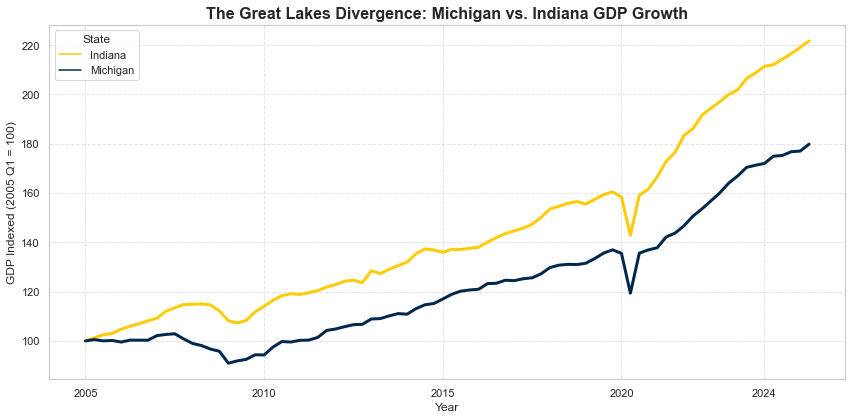

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
econ_df = pd.read_csv('economics.csv')

# Filter for the two states
states = ['Michigan', 'Indiana']
df = econ_df[econ_df['State'].isin(states)].copy()

# Create a continuous time axis
df['Date'] = df['Year'] + (df['Quarter'] - 1) / 4
df = df.sort_values(['State', 'Date'])

# Index GDP to 2005 Q1 = 100
base_vals = df.groupby('State')['GDP_Total'].transform('first')
df['GDP_Indexed'] = (df['GDP_Total'] / base_vals) * 100

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='GDP_Indexed', hue='State', 
             linewidth=3, palette={'Michigan': '#00274C', 'Indiana': '#FFCB05'})

# Fix x-axis ticks to specific years as integers
tick_years = [2005, 2010, 2015, 2020, 2024]
plt.xticks(tick_years, [int(y) for y in tick_years])

plt.title('The Great Lakes Divergence: Michigan vs. Indiana GDP Growth', fontsize=16, fontweight='bold')
plt.ylabel('GDP Indexed (2005 Q1 = 100)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('gdp_divergence_final.png')

In [ ]:
# How to implement our recommendations; who is it addressed to?
# Include solid numbers